In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import os

sns.set_style('whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)

train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

# Các feature
features_num = ['dien_tich_log', 'phong_ngu', 'phong_tam', 'so_tang']
features_cat = ['quan', 'thanh_pho', 'phap_ly']

# Tách dữ liệu
X_train_raw = train_df[features_num + features_cat]
y_train = train_df['gia_log']

X_test_raw = test_df[features_num + features_cat]
y_test_original = test_df['gia']

# one-hot encoding tham khảo từ model 1
X_train_encoded = pd.get_dummies(X_train_raw, columns=features_cat, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, columns=features_cat, drop_first=True)

# Đồng bộ cột
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Số lượng features sau encoding: {X_train_encoded.shape[1]}")

# Polinomial
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train = poly.fit_transform(X_train_encoded)
X_test = poly.transform(X_test_encoded)

print(f"Số lượng features sau Polynomial: {X_train.shape[1]}")

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Huấn luyện mô hình hoàn tất!")
print(f"Hệ số chặn (Intercept): {model.intercept_:.4f}")

# Prediction
y_pred_log = model.predict(X_test)

# Chuyển về giá gốc
y_pred_original = np.expm1(y_pred_log)

# Evaluation
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

results = pd.DataFrame({
    'Metric': [
        'R-squared (R2)', 
        'Mean Absolute Error (MAE)', 
        'Mean Squared Error (MSE)', 
        'Root Mean Squared Error (RMSE)'
    ],
    'Value': [
        f"{r2:.4f}", 
        f"{mae:.4f} Tỷ VNĐ", 
        f"{mse:.4f} Tỷ^2", 
        f"{rmse:.4f} Tỷ VNĐ"
    ]
})

print("HIỆU SUẤT MODEL 3 (POLY + LOCATION FEATURES)")
display(results)


Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)
Số lượng features sau encoding: 38
Số lượng features sau Polynomial: 779
Huấn luyện mô hình hoàn tất!
Hệ số chặn (Intercept): -0.8626
HIỆU SUẤT MODEL 3 (POLY + LOCATION FEATURES)


,Metric,Value
0,R-squared (R2),0.7512
1,Mean Absolute Error (MAE),2.6281 Tỷ VNĐ
2,Mean Squared Error (MSE),24.3364 Tỷ^2
3,Root Mean Squared Error (RMSE),4.9332 Tỷ VNĐ


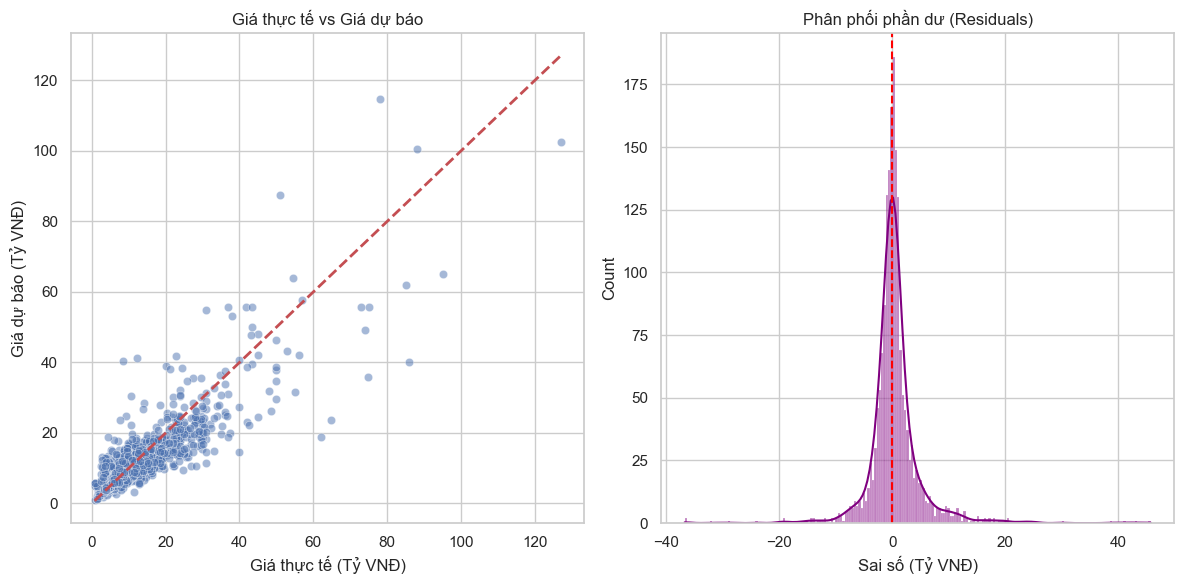

In [10]:
# VISUALIZATION 
plt.figure(figsize=(12, 6))

residuals = y_test_original - y_pred_original

# Scatter plot 
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)

plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)

plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# Residual 
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')

plt.title("Phân phối phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()

In [11]:
print(f"Model: Polynomial Regression + Location Features")
print(f"R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

Model: Polynomial Regression + Location Features
R2: 0.7512 | MAE: 2.6281 | MSE: 24.3364 | RMSE: 4.9332
